# Tracking × calls

## What the tracking repo gives us

One CSV per video, at `Video/<date>/<exp>/video_<camera>_<idx>.csv`. **One row = one animal seen in
one frame.**

| column | meaning |
|---|---|
| `frame_id` | frame number; **seconds into the video = `frame_id / 30`** |
| `det_id` | index within that frame only — **resets every frame, it is NOT an identity** |
| `conf` | detection confidence, 0–1 (below 0.25 already dropped) |
| `center_x`, `center_y` | position in **cm**, arena is 121 × 91 |
| `bbox_*` | box in **pixels** of the 1600×1200 frame — different coordinate system, don't mix |
| `stationary` | **0/1 — the detector locked onto a fixed object, not an animal** |

Three things that bite if forgotten:

- **No identity across frames.** We can count animals and locate them; we cannot follow one.
- **Empty frames are omitted**, so a missing frame means "nothing detected", and row count ≠ frame count.
- **Positions are clamped** into the arena, so detections outside it pile up exactly on the bounds.

## How we read it here

`scripts/pipeline/pool_detections.py --date-folder <DATE>` turns those CSVs into two files per date
folder, and everything below reads those, never the raw CSVs:

- **`detections_<date>.parquet`** — every detection, plus `exp`, `location` (`arena_1`/`arena_2`,
  the same vocabulary the calls use — camera names stay in the filenames), and **`start_time_real`,
  the same clock as `all_calls`**, so a call and a detection at the same moment join directly.
- **`files_vetted_<date>.csv`** — one row per video that was tracked. This is how "nobody was
  visible" is told apart from "that video was never looked at"; without it, both are just absent
  rows. It also carries `stationary_source`.

**Neither rule is left to memory.**

1. **`pool_detections.py` removes the stationary rows when it pools** — the file you read is already
   clean, whatever you open it with. The per-experiment files keep them as the audit trail, and
   `files_vetted.n_stationary` counts what went.
2. **`scripts/utils/tracking_io.py` handles the filmed-minutes rule** — `animals_per_minute()` counts
   only minutes that were tracked, so a quiet minute is a zero and an untracked one is absent.

For reference, the rules themselves:

1. **Stationary detections must go** — 13% of arena_2 in 2026_02 (a piece of plastic a gerbil
   dragged in). Occupancy is meaningless without removing them.
2. **Count minutes from `files_vetted`, not from the detections** — otherwise an untracked camera
   silently becomes an empty arena.

`stationary_source` says who computed the flag: `detector` (the tracking repo, the good one) or
`fallback` (our coarser local rule, still used for 5 experiments they have not reached — those are
under-flagged, so treat them as provisional).

Caveat unrelated to the video: calls are assigned to whichever channel DAS fired on, and arena_1
calls leak into arena_2. Read arena_1 with confidence, arena_2 with suspicion.

## Two layers of data, and which to use

The raw detections are ~260 MB **per experiment** — too much to hold for the whole cohort, and a
JupyterHub session here only gets 16 GB. So `scripts/pipeline/build_behaviour.py` reduces each date
folder once into two small tables, and most of this notebook reads those:

| | what it is | size |
|---|---|---|
| `load_behaviour_seconds(DATE)` | one row per (exp, location, **filmed second**): `n_detections`, `animals`, `n_calls` | ~10 MB |
| `load_occupancy_cells(DATE)` | animal-seconds per 2 cm cell, per experiment and location | 0.2 MB |

Both hold the whole cohort at once, and both are built from exactly the rows that survived vetting —
artifacts and out-of-sync chunks already removed — so they agree with the pooled detections to the
decimal.

**Raw detections are still needed for anything below one second or finer than a 2 cm cell** — the
inter-animal spacing section walks frames, so it loads one experiment at a time. Neural work will be
the same: one experiment, raw.

If you add a cell: prefer `seconds` and `cells`; reach for `load_detections(DATE, exp=...)` only when
you truly need per-frame positions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.utils.tracking_io import (load_behaviour_seconds, load_occupancy_cells,
                                       load_detections, load_files_vetted,
                                       experiments_in, FPS, FRAMES_PER_MINUTE)
from scripts.pipeline.pool_calls import add_exp_times

DATE = "2026_02"

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2.0})
COLOURS = {"arena_1": "#4c6ef5", "arena_2": "#f08c00"}

In [2]:
# Two layers, and this cell loads both — see the note above.
seconds = load_behaviour_seconds(DATE)      # whole cohort, ~10 MB
cells = load_occupancy_cells(DATE)          # whole cohort, 0.2 MB
videos = load_files_vetted(DATE)
all_experiments = experiments_in(DATE)

# One experiment's raw detections, only to look at the row format below.
detections = load_detections(DATE, exp=all_experiments[0])

print(f"{len(seconds):,} filmed seconds and {len(cells):,} occupied cells "
      f"from {len(all_experiments)} experiments")

2026_02: 233,338 detections (0 stationary dropped, 0.0%)
1,527,120 filmed seconds and 118,375 occupied cells from 28 experiments


## 1. The data, and how to work with it

One row per animal seen in one frame.

In [3]:
detections.head(3)

,exp,location,file_num,frame_id,det_id,conf,center_x,center_y,bbox_x1,bbox_y1,bbox_x2,bbox_y2,start_time_real,stationary
0,492,arena_1,2,5725,0,0.7800,100.33,70.88,1197,844,1273,931,2026-02-18 15:55:51.833333333,False
1,492,arena_1,2,5726,0,0.6975,100.42,70.79,1197,846,1274,930,2026-02-18 15:55:51.866666667,False
2,492,arena_1,2,5727,0,0.5128,100.23,70.60,1197,843,1274,927,2026-02-18 15:55:51.900000000,False


In [4]:
# --- the three manipulations used throughout ---

# a) FILTER rows with a condition in square brackets
arena_1_only = detections[detections.location == "arena_1"]
print("filter :", len(arena_1_only), "rows in arena_1")

# b) ADD a column by computing from existing ones
one_video = detections[(detections.exp == 492) & (detections.file_num == 2)].copy()
one_video["seconds_into_video"] = one_video["frame_id"] / FPS
print("new col:", one_video[["frame_id", "seconds_into_video"]].head(2).to_dict("records"))

# c) GROUP rows and count / average within each group
per_location = detections.groupby("location").size()
print("group  :", per_location.to_dict())

filter : 216752 rows in arena_1
new col: [{'frame_id': 5725, 'seconds_into_video': 190.83333333333334}, {'frame_id': 5726, 'seconds_into_video': 190.86666666666667}]
group  : {'arena_1': 216752, 'arena_2': 16586}


/tmp/ipykernel_123217/3568138662.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_location = detections.groupby("location").size()


**`.copy()` matters in (b).** `one_video` is a slice of `detections`; without `.copy()` pandas warns
that you are assigning into a view of the original. Copy first, then add columns.

**Careful with column names.** `df.sem` and `df.mean` give you pandas *methods*, not your columns of
those names — that is why the columns below are `error` and `mean_per_animal`. When in doubt use
`df["name"]`, which always means the column.

## 2. Minutes: how many animals, how many calls

One row per experiment, location and minute.

In [5]:
# (animals_per_minute and calls_per_minute are no longer needed here — the
# behaviour table already holds both, per second.)

In [6]:
# Re-bin the per-second table to minutes. This replaces a loop that re-read every
# experiment's detections; the numbers are identical because the seconds table was
# built from exactly the same rows.
seconds["minute"] = seconds["second"].dt.floor("1min")

minutes = seconds.groupby(["exp", "location", "minute"], observed=True).agg(
    animals=("animals", "mean"),      # mean animals visible per frame, over the minute
    calls=("n_calls", "sum"),
).reset_index()

minutes = minutes[minutes.location.isin(["arena_1", "arena_2"])]
print(f"{len(minutes):,} filmed minutes")
minutes.head(3)

25,505 filmed minutes


,exp,location,minute,animals,calls
0,492,arena_1,2026-02-18 15:40:00,0.0,0
1,492,arena_1,2026-02-18 15:41:00,0.0,0
2,492,arena_1,2026-02-18 15:42:00,0.0,0


## 3. The two arenas side by side

Same minutes, one column per arena — easier to compare than the stacked form above.

In [7]:
arena_1 = minutes[minutes.location == "arena_1"]
arena_2 = minutes[minutes.location == "arena_2"]

side_by_side = arena_1.merge(arena_2, on=["exp", "minute"], suffixes=("_1", "_2"))
side_by_side = side_by_side[["exp", "minute", "animals_1", "calls_1", "animals_2", "calls_2"]]

print(f"{len(side_by_side):,} minutes where BOTH arenas were filmed")
side_by_side.head(5)

12,127 minutes where BOTH arenas were filmed


,exp,minute,animals_1,calls_1,animals_2,calls_2
0,492,2026-02-18 15:40:00,0.0,0,0.0,0
1,492,2026-02-18 15:41:00,0.0,0,0.0,0
2,492,2026-02-18 15:42:00,0.0,0,0.0,0
3,492,2026-02-18 15:43:00,0.0,0,0.0,0
4,492,2026-02-18 15:44:00,0.0,0,0.0,0


In [8]:
print(side_by_side[["animals_1", "calls_1", "animals_2", "calls_2"]].describe().round(2))

       animals_1   calls_1  animals_2   calls_2
count   12127.00  12127.00   12127.00  12127.00
mean        0.63      7.57       0.47      5.63
std         0.90     15.63       0.78     14.69
min         0.00      0.00       0.00      0.00
25%         0.00      0.00       0.00      0.00
50%         0.00      0.00       0.00      0.00
75%         1.05      8.00       0.87      2.00
max         6.33    160.00       5.40    204.00


### Where they spend their time

Occupancy as a map: 2 cm cells over the 121 × 91 cm arena. Each panel is the share of **that arena's**
detections, so the two are comparable in shape even though arena_1 sees far more traffic. One hue,
light to dark — a rainbow would invent boundaries the data doesn't have.

In [9]:
ARENA_WIDTH_CM, ARENA_HEIGHT_CM = 121, 91
BIN_CM = 2

x_edges = np.arange(0, ARENA_WIDTH_CM + BIN_CM, BIN_CM)
y_edges = np.arange(0, ARENA_HEIGHT_CM + BIN_CM, BIN_CM)

# One arena at a time: 26M rows will not fit comfortably if we hold both.
occupancy_maps = {}
for location in ["arena_1", "arena_2"]:
    points = load_detections(DATE, location=location, quiet=True,
                             columns=["center_x", "center_y"])
    counts, _, _ = np.histogram2d(points.center_x, points.center_y, bins=[x_edges, y_edges])
    occupancy_maps[location] = 100 * counts / counts.sum()
    print(f"{location}: {len(points):,} detections")
    del points

arena_1: 13,678,934 detections


arena_2: 11,725,779 detections


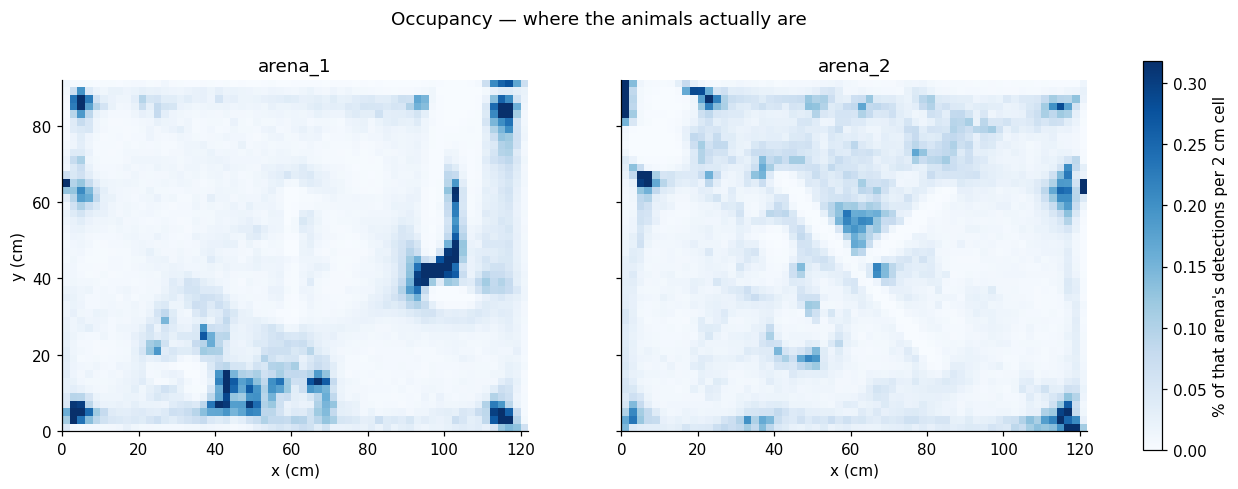

In [10]:
# One shared colour scale, capped at the 99th percentile so a couple of hot cells
# do not flatten everything else.
busiest = [np.percentile(m[m > 0], 99) for m in occupancy_maps.values()]
top = max(busiest)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True, sharey=True)

for ax, location in zip(axes, ["arena_1", "arena_2"]):
    heat = occupancy_maps[location]
    mesh = ax.pcolormesh(x_edges, y_edges, heat.T, cmap="Blues",
                         vmin=0, vmax=top, shading="auto")
    ax.set_title(location)
    ax.set_xlabel("x (cm)")
    ax.set_aspect("equal")
    ax.grid(False)

axes[0].set_ylabel("y (cm)")
fig.colorbar(mesh, ax=axes, label=f"% of that arena's detections per {BIN_CM} cm cell",
             fraction=0.025)
fig.suptitle("Occupancy — where the animals actually are")
plt.show()

Edges and corners are real wall-following, but remember positions are **clamped** into the arena, so
a detection just outside lands exactly on the boundary — the outermost row of cells is inflated.

### The same map in seconds — the denominator for rate maps

Percentages tell you the *shape* of arena use but cannot be divided into anything. For that we need
**time**: one detection is one animal seen for one frame, so it is `1 / 30` s of **animal-time** in
its cell. Summing gives **animal-seconds per cell**.

That is the denominator. Later, any positional event count — calls, spikes — divided by this map
gives **events per animal-second at each position**, which is the usual way a rate map is built.

Two things to keep straight:

- The unit is *animal*-seconds, not wall-clock seconds. Two animals in a cell for one second is two
  animal-seconds — which is what you want, since a rate per animal is the comparable quantity.
- Cells observed for only a moment give wild rates when you divide by them, so `rate_map` blanks any
  cell below `MIN_OCCUPANCY_SECONDS`.

In [11]:
def occupancy_map(location, exp=None):
    """Animal-seconds per cell, from the reduced table — no raw detections needed.

    Pass exp= for one experiment's map; leave it out for the whole date folder.
    """
    chosen = cells[cells.location == location]
    if exp is not None:
        chosen = chosen[chosen.exp == exp]

    grid = np.zeros((len(x_edges) - 1, len(y_edges) - 1))
    x_index = (chosen.x_cm / BIN_CM).astype(int)
    y_index = (chosen.y_cm / BIN_CM).astype(int)
    np.add.at(grid, (x_index.to_numpy(), y_index.to_numpy()), chosen.animal_seconds.to_numpy())
    return grid


occupancy_seconds = {}
for location in ["arena_1", "arena_2"]:
    occupancy_seconds[location] = occupancy_map(location)
    print(f"{location}: {occupancy_seconds[location].sum() / 3600:8.1f} animal-hours "
          f"over {len(all_experiments)} experiments")

arena_1:    126.7 animal-hours over 28 experiments
arena_2:    108.6 animal-hours over 28 experiments


In [12]:
# Sanity check: animal-hours / filmed-hours should equal the mean animals visible.
# The seconds table has one row per filmed second, so counting rows gives filmed time.
filmed_hours = seconds.groupby("location", observed=True).size() / 3600

for location in ["arena_1", "arena_2"]:
    animal_hours = occupancy_seconds[location].sum() / 3600
    print(f"{location}: {filmed_hours[location]:7.1f} filmed hours, {animal_hours:7.1f} animal-hours "
          f"-> {animal_hours / filmed_hours[location]:.2f} animals visible on average")

arena_1:   201.8 filmed hours,   126.7 animal-hours -> 0.63 animals visible on average
arena_2:   222.4 filmed hours,   108.6 animal-hours -> 0.49 animals visible on average


In [13]:
MIN_OCCUPANCY_SECONDS = 5.0     # below this, a cell's rate is noise

def rate_map(event_x, event_y, seconds):
    """Events per animal-second in each cell, NaN where we barely observed.

    `seconds` is an occupancy_map(...) — use the one for the SAME experiment as
    the events, not the pooled one (see the stability check below).
    """
    events, _, _ = np.histogram2d(event_x, event_y, bins=[x_edges, y_edges])

    rate = np.full(events.shape, np.nan)
    enough = seconds >= MIN_OCCUPANCY_SECONDS
    rate[enough] = events[enough] / seconds[enough]
    return rate


for location in ["arena_1", "arena_2"]:
    grid = occupancy_seconds[location]
    usable = (grid >= MIN_OCCUPANCY_SECONDS).mean()
    print(f"{location}: {100*usable:.0f}% of cells have >= {MIN_OCCUPANCY_SECONDS:g}s "
          f"(median {np.median(grid[grid > 0]):.0f}s where visited)")

arena_1: 98% of cells have >= 5s (median 68s where visited)
arena_2: 97% of cells have >= 5s (median 79s where visited)


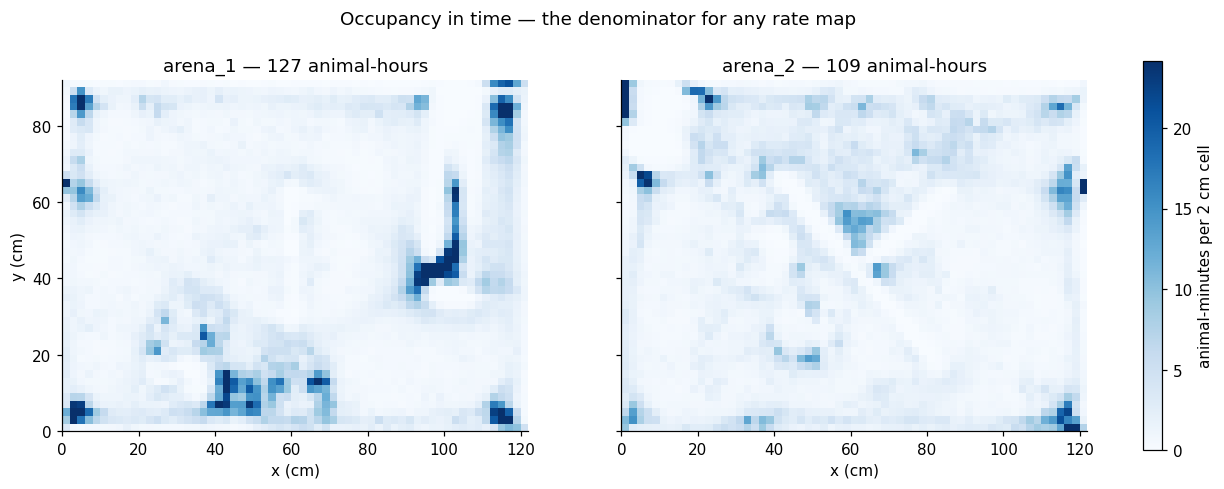

In [14]:
# Shown in minutes so the numbers are readable; the array itself stays in seconds.
top_minutes = max(np.percentile(m[m > 0] / 60, 99) for m in occupancy_seconds.values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True, sharey=True)

for ax, location in zip(axes, ["arena_1", "arena_2"]):
    mesh = ax.pcolormesh(x_edges, y_edges, (occupancy_seconds[location] / 60).T,
                         cmap="Blues", vmin=0, vmax=top_minutes, shading="auto")
    ax.set_title(f"{location} — {occupancy_seconds[location].sum()/3600:,.0f} animal-hours")
    ax.set_xlabel("x (cm)")
    ax.set_aspect("equal")
    ax.grid(False)

axes[0].set_ylabel("y (cm)")
fig.colorbar(mesh, ax=axes, label=f"animal-minutes per {BIN_CM} cm cell", fraction=0.025)
fig.suptitle("Occupancy in time — the denominator for any rate map")
plt.show()

Both arenas share one colour scale here, so the panels are comparable in absolute time — unlike the
percentage maps above, where each was normalised to itself.

To use it later:

```python
rate = rate_map(events.center_x, events.center_y, "arena_1")   # events per animal-second
```

### Is one pooled map even legitimate?

The pooled map covers **28 experiments over 10 days**, and the arena did not stay the same — a piece
of plastic arrived on 22 Feb and left on the 24th, another object appeared later. If the animals use
the space differently from one experiment to the next, a pooled denominator divides events from one
configuration by occupancy averaged over others.

Test it: correlate each experiment's map against every other.

In [15]:
busy_experiments = [497, 501, 504, 505, 508, 512, 513, 517, 519]

experiment_maps = {}
for exp in busy_experiments:
    grid = occupancy_map("arena_1", exp=exp)
    if grid.sum() / 3600 < 3:          # skip experiments with little observed time
        continue
    experiment_maps[exp] = grid.ravel()

keys = sorted(experiment_maps)
correlations = pd.DataFrame(index=keys, columns=keys, dtype=float)
for a in keys:
    for b in keys:
        correlations.loc[a, b] = np.corrcoef(experiment_maps[a], experiment_maps[b])[0, 1]

off_diagonal = correlations.values[~np.eye(len(keys), dtype=bool)]
print(f"pairwise correlation: median {np.median(off_diagonal):.2f}, "
      f"range {off_diagonal.min():.2f}-{off_diagonal.max():.2f}")
correlations.round(2)

pairwise correlation: median 0.45, range 0.13-0.75


,497,501,504,505,508,512,513,517,519
497,1.00,0.16,0.26,0.21,0.13,0.17,0.20,0.18,0.15
501,0.16,1.00,0.52,0.41,0.21,0.24,0.28,0.24,0.21
504,0.26,0.52,1.00,0.59,0.47,0.65,0.59,0.52,0.53
505,0.21,0.41,0.59,1.00,0.32,0.47,0.51,0.46,0.46
508,0.13,0.21,0.47,0.32,1.00,0.44,0.53,0.33,0.43
512,0.17,0.24,0.65,0.47,0.44,1.00,0.65,0.45,0.58
513,0.20,0.28,0.59,0.51,0.53,0.65,1.00,0.54,0.59
517,0.18,0.24,0.52,0.46,0.33,0.45,0.54,1.00,0.75
519,0.15,0.21,0.53,0.46,0.43,0.58,0.59,0.75,1.00


Median **~0.5**, and as low as 0.15 for exp 497 — so the pooled map is a blend of configurations,
not one stable picture. Experiments close in time agree best, which is what you would expect if the
furniture and the animals' habits drift over the ten days.

**So for a rate map, build the denominator per experiment**, matching the events:

```python
seconds = occupancy_map("arena_1", exp=508)
rate    = rate_map(events.center_x, events.center_y, seconds)
```

The pooled map is still the right thing for "where do they generally go", just not for dividing.

## 4. Call rate vs number of animals

In [16]:
minutes = minutes.copy()
minutes["n_animals"] = minutes["animals"].round()

summary = minutes.groupby(["location", "n_animals"]).agg(
    mean_calls=("calls", "mean"),
    error=("calls", "sem"),               # standard error, for the error bars
    n_minutes=("calls", "size"),
).reset_index()

summary = summary[summary.n_minutes >= 20]
summary

,location,n_animals,mean_calls,error,n_minutes
0,arena_1,0.0,0.574196,0.032362,7433
1,arena_1,1.0,9.945689,0.247500,2633
2,arena_1,2.0,25.066989,0.504027,1448
3,arena_1,3.0,38.015625,1.098020,512
4,arena_1,4.0,48.732558,3.191534,86
7,arena_2,0.0,0.446888,0.034964,9094
8,arena_2,1.0,8.614407,0.271825,2596
9,arena_2,2.0,26.776967,0.652183,1233
10,arena_2,3.0,37.170483,1.326687,393
11,arena_2,4.0,55.685185,5.100789,54


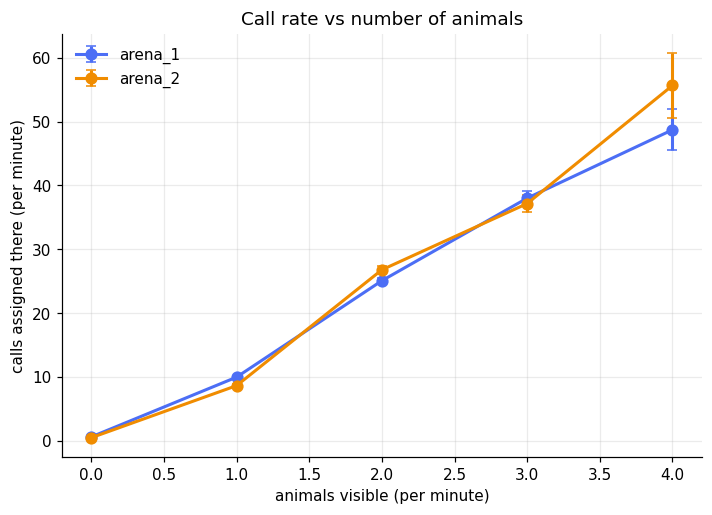

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for location in ["arena_1", "arena_2"]:
    r = summary[summary.location == location]
    ax.errorbar(r.n_animals, r.mean_calls, yerr=r["error"], fmt="o-",
                color=COLOURS[location], markersize=7, capsize=3, label=location)
ax.set_xlabel("animals visible (per minute)")
ax.set_ylabel("calls assigned there (per minute)")
ax.set_title("Call rate vs number of animals")
ax.legend(frameon=False)
plt.show()

## 5. Calls per animal — and is the rise linear?

**If call rate rose linearly with headcount, calls per animal would be a flat line.** That is the whole
test: divide by `n_animals` and look for flatness. Rising = each animal calls more when it has
company (superlinear); falling = each calls less (sublinear).

The error bars decide whether a bend is real or just few minutes.

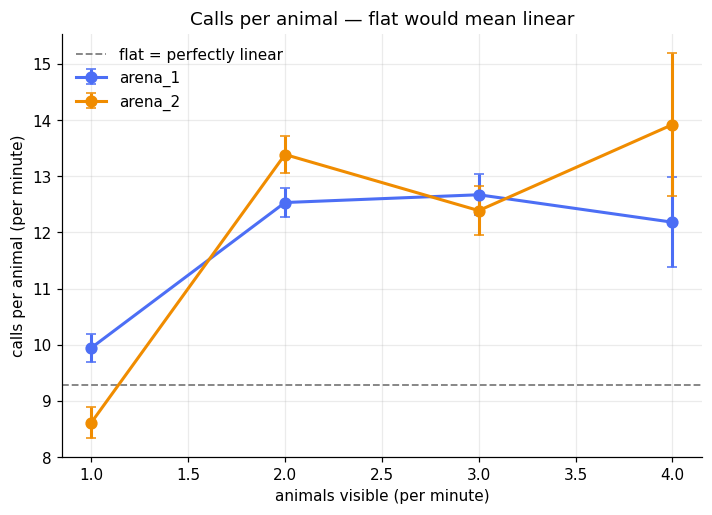

  location  n_animals  mean_per_animal  error  n_minutes
0  arena_1        1.0             9.95   0.25       2633
1  arena_1        2.0            12.53   0.25       1448
2  arena_1        3.0            12.67   0.37        512
3  arena_1        4.0            12.18   0.80         86
6  arena_2        1.0             8.61   0.27       2596
7  arena_2        2.0            13.39   0.33       1233
8  arena_2        3.0            12.39   0.44        393
9  arena_2        4.0            13.92   1.28         54


In [18]:
per_animal = minutes[minutes.n_animals >= 1].copy()
per_animal["calls_per_animal"] = per_animal["calls"] / per_animal["n_animals"]

summary_per_animal = per_animal.groupby(["location", "n_animals"]).agg(
    mean_per_animal=("calls_per_animal", "mean"),
    error=("calls_per_animal", "sem"),
    n_minutes=("calls_per_animal", "size"),
).reset_index()
summary_per_animal = summary_per_animal[summary_per_animal.n_minutes >= 20]

fig, ax = plt.subplots(figsize=(7.5, 5))
for location in ["arena_1", "arena_2"]:
    r = summary_per_animal[summary_per_animal.location == location]
    ax.errorbar(r.n_animals, r["mean_per_animal"], yerr=r["error"], fmt="o-",
                color=COLOURS[location], markersize=7, capsize=3, label=location)
ax.axhline(summary_per_animal[summary_per_animal.n_animals == 1]["mean_per_animal"].mean(),
           color="0.5", ls="--", lw=1.2, label="flat = perfectly linear")
ax.set_xlabel("animals visible (per minute)")
ax.set_ylabel("calls per animal (per minute)")
ax.set_title("Calls per animal — flat would mean linear")
ax.legend(frameon=False)
plt.show()

print(summary_per_animal.round(2))

### Putting a number on it

Fit `calls = a · n^b`. Taking logs makes it a straight line, so `b` comes from a linear fit:

- **b = 1** → exactly linear (double the animals, double the calls)
- **b > 1** → superlinear, animals call more in company
- **b < 1** → sublinear

In [19]:
for location in ["arena_1", "arena_2"]:
    d = minutes[(minutes.location == location) & (minutes.n_animals >= 1) & (minutes.calls > 0)]

    log_animals = np.log(d["n_animals"].to_numpy(float))
    log_calls = np.log(d["calls"].to_numpy(float))

    # slope of a straight line = covariance / variance. (np.polyfit does this via
    # an SVD, which occasionally fails to converge here.)
    b = np.cov(log_animals, log_calls)[0, 1] / np.var(log_animals, ddof=1)
    intercept = log_calls.mean() - b * log_animals.mean()

    # rough uncertainty on b: scatter of the residuals / spread of x
    residuals = log_calls - (b * log_animals + intercept)
    se = residuals.std() / (log_animals.std() * np.sqrt(len(d)))

    print(f"{location}: b = {b:.2f} ± {1.96*se:.2f}   (n = {len(d):,} minutes)")

arena_1: b = 1.27 ± 0.07   (n = 4,059 minutes)
arena_2: b = 1.35 ± 0.09   (n = 3,346 minutes)


## 6. How far apart are the animals?

The goal: **do calls happen when animals are close together, or far apart?**

Two decisions worth stating, because they shape the answer.

**How many neighbours.** Distance to the *k* nearest neighbours needs k+1 animals visible at once.
For k=3 that is 4+ animals, which happens in only **4.5%** of arena_1 frames — and those are the
busiest moments, which we already know are the most vocal. k=1 needs 2 animals: **46.6%** of frames.
`K_NEIGHBOURS` below is a parameter; try 3 and watch the usable frames collapse.

**Crowding is a confound.** More animals in a fixed arena means smaller distances, automatically. And
call rate already rises with headcount. So we always compare **within the same number of animals**,
never across.

In [20]:
K_NEIGHBOURS = 1        # 1 = distance to the closest other animal. Try 3 to see the cost.
ARENA = "arena_1"       # the arena whose call assignment we trust


In [21]:
from scipy.spatial.distance import pdist, squareform


def mean_distance_to_neighbours(x_values, y_values, k):
    """Mean distance from each animal to its k nearest neighbours, in cm.

    Returns NaN when there are not enough animals in the frame (needs k+1).
    """
    if len(x_values) < k + 1:
        return np.nan

    points = np.column_stack([x_values, y_values])
    distances = squareform(pdist(points))      # square matrix, animal x animal
    np.fill_diagonal(distances, np.inf)        # ignore each animal's distance to itself

    distances.sort(axis=1)                     # each row: neighbours nearest first
    nearest_k = distances[:, :k]
    return nearest_k.mean()

In [22]:
# One experiment at a time, keeping only the small per-frame result.
# One frame per second is plenty: animals barely move in 1/30 s, and it is 30x cheaper.
spacing_rows = []
for exp in all_experiments:
    positions = load_detections(DATE, exp=exp, location=ARENA, quiet=True,
                                columns=["file_num", "frame_id", "center_x", "center_y",
                                         "start_time_real"])
    positions = positions[positions.frame_id % FPS == 0]

    for (file_num, frame_id), frame in positions.groupby(["file_num", "frame_id"]):
        distance = mean_distance_to_neighbours(frame.center_x.values, frame.center_y.values,
                                               K_NEIGHBOURS)
        if np.isnan(distance):
            continue
        spacing_rows.append({"exp": exp, "file_num": file_num, "frame_id": frame_id,
                             "time": frame.start_time_real.iloc[0],
                             "n_animals": len(frame), "distance": distance})

spacing = pd.DataFrame(spacing_rows)
print(f"{len(spacing):,} frames usable with K_NEIGHBOURS={K_NEIGHBOURS}")
print(spacing.groupby("n_animals")["distance"].agg(["size", "mean"]).round(1).head())

147,890 frames usable with K_NEIGHBOURS=1
            size  mean
n_animals             
2          96138  55.2
3          38151  39.4
4          10760  31.1
5           2290  25.8
6            452  21.9


### Was there a call at that second?

Mark each frame with whether a call was assigned to this arena within that second, then compare the
spacing of calling seconds against silent ones — **separately for each animal count**.

In [23]:
call_seconds = set()
for exp in sorted(spacing.exp.unique()):
    c = add_exp_times(exp)
    c = c[c.assigned_location == ARENA]
    for t in c.start_time_real.dt.floor("s"):
        call_seconds.add((exp, t))

spacing["second"] = spacing["time"].dt.floor("s")
spacing["has_call"] = [(e, s) in call_seconds for e, s in zip(spacing.exp, spacing.second)]
print(f"{spacing.has_call.sum():,} of {len(spacing):,} frames had a call in that second")

38,966 of 147,890 frames had a call in that second


In [24]:
comparison = spacing.groupby(["n_animals", "has_call"]).agg(
    mean_distance=("distance", "mean"),
    error=("distance", "sem"),
    n_frames=("distance", "size"),
).reset_index()

comparison = comparison[comparison.n_frames >= 50]
comparison.round(2)

,n_animals,has_call,mean_distance,error,n_frames
0,2,False,57.32,0.13,74685
1,2,True,47.70,0.23,21453
2,3,False,40.61,0.13,26226
3,3,True,36.71,0.17,11925
4,4,False,32.44,0.18,6572
5,4,True,29.06,0.21,4188
6,5,False,26.88,0.30,1195
7,5,True,24.65,0.32,1095
8,6,False,23.12,0.59,197
9,6,True,20.99,0.46,255


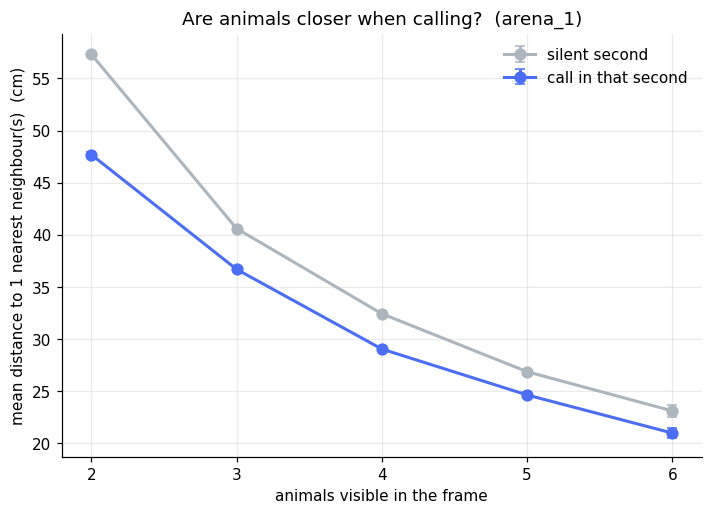

In [25]:
counts = sorted(comparison.n_animals.unique())
fig, ax = plt.subplots(figsize=(7.5, 5))

for has_call, colour, label in [(False, "#adb5bd", "silent second"), (True, "#4c6ef5", "call in that second")]:
    rows_ = comparison[comparison.has_call == has_call]
    ax.errorbar(rows_.n_animals, rows_.mean_distance, yerr=rows_["error"],
                fmt="o-", color=colour, markersize=7, capsize=3, label=label)

ax.set_xlabel("animals visible in the frame")
ax.set_ylabel(f"mean distance to {K_NEIGHBOURS} nearest neighbour(s)  (cm)")
ax.set_title(f"Are animals closer when calling?  ({ARENA})")
ax.set_xticks(counts)
ax.legend(frameon=False)
plt.show()

Compare the two lines **at the same x** — that is the whole point of splitting by animal count. A
gap between them means spacing differs between calling and silent moments for the *same* number of
animals, so it is not just crowding.

Caveats: a call is attributed to the arena by audio, which is unreliable for arena_2 (hence
`ARENA = "arena_1"`); animals in the burrow are invisible; and a second is coarse — a call lasts tens
of milliseconds, so this asks "were they close around the time of the call", not "at the instant".

## Questions next

1. **Time of day is a confound.** Occupancy and calling both vary over the day, so this relationship
   could be hours, not company. Compare minutes *within the same hour* to separate them.
2. Does the slope hold in most of the 28 experiments, or is it carried by a few?
3. Split by **call type** — more robust than location in the current calls table.

## 7. Day by day

The pooled map hides ten days of change. Split it: how much time do they spend visible each day, and
does the *shape* of arena use drift?

Built one experiment at a time and accumulated into day bins — an experiment can cross midnight, so
the day comes from each detection's own timestamp, not the experiment's.

In [26]:
DAY_LOCATION = "arena_1"

daily_seconds = {}          # date -> animal-seconds per cell

for exp in all_experiments:
    points = load_detections(DATE, exp=exp, location=DAY_LOCATION, quiet=True,
                             columns=["center_x", "center_y", "start_time_real"])
    if len(points) == 0:
        continue

    points = points.copy()
    points["day"] = points["start_time_real"].dt.date

    for day, rows in points.groupby("day"):
        counts, _, _ = np.histogram2d(rows.center_x, rows.center_y, bins=[x_edges, y_edges])
        if day not in daily_seconds:
            daily_seconds[day] = np.zeros_like(counts)
        daily_seconds[day] += counts / FPS

days = sorted(daily_seconds)
print(f"{len(days)} days, {days[0]} to {days[-1]}")

12 days, 2026-02-18 to 2026-03-01


In [27]:
# Filmed time per day — again just counting rows of the seconds table.
day_seconds = seconds[seconds.location == DAY_LOCATION].copy()
day_seconds["day"] = day_seconds["second"].dt.date
filmed_hours_per_day = day_seconds.groupby("day").size() / 3600

summary_by_day = pd.DataFrame({
    "animal_hours": {d: daily_seconds[d].sum() / 3600 for d in days},
    "filmed_hours": filmed_hours_per_day,
}).dropna()
summary_by_day["animals_visible"] = summary_by_day.animal_hours / summary_by_day.filmed_hours
summary_by_day.round(2)

,animal_hours,filmed_hours,animals_visible
2026-02-18,9.04,8.31,1.09
2026-02-19,11.99,21.18,0.57
2026-02-20,13.47,23.91,0.56
2026-02-21,13.36,23.87,0.56
2026-02-22,14.50,24.03,0.60
2026-02-23,7.95,13.96,0.57
2026-02-24,16.60,16.19,1.03
2026-02-25,16.89,18.05,0.94
2026-02-26,3.32,6.44,0.52
2026-02-27,18.28,23.11,0.79


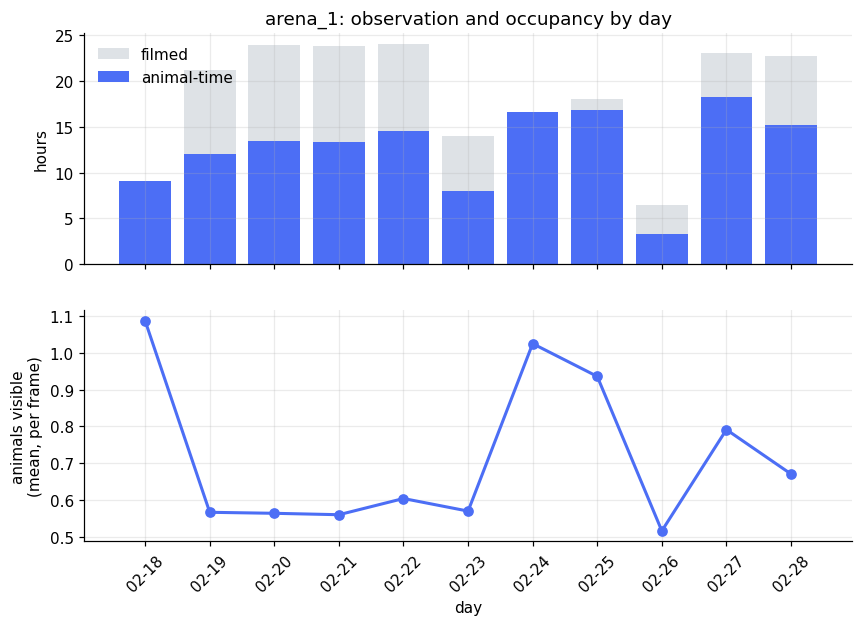

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].bar(range(len(summary_by_day)), summary_by_day.filmed_hours,
            color="#dee2e6", label="filmed")
axes[0].bar(range(len(summary_by_day)), summary_by_day.animal_hours,
            color=COLOURS["arena_1"], label="animal-time")
axes[0].set_ylabel("hours")
axes[0].legend(frameon=False)
axes[0].set_title(f"{DAY_LOCATION}: observation and occupancy by day")

axes[1].plot(range(len(summary_by_day)), summary_by_day.animals_visible, "o-",
             color=COLOURS["arena_1"])
axes[1].set_ylabel("animals visible\n(mean, per frame)")
axes[1].set_xticks(range(len(summary_by_day)))
axes[1].set_xticklabels([d.strftime("%m-%d") for d in summary_by_day.index], rotation=45)
axes[1].set_xlabel("day")
plt.show()

### Does the *shape* of arena use drift?

Each day normalised to its own total, so this is about where they go, not how much they are out. One
shared colour scale across the panels.

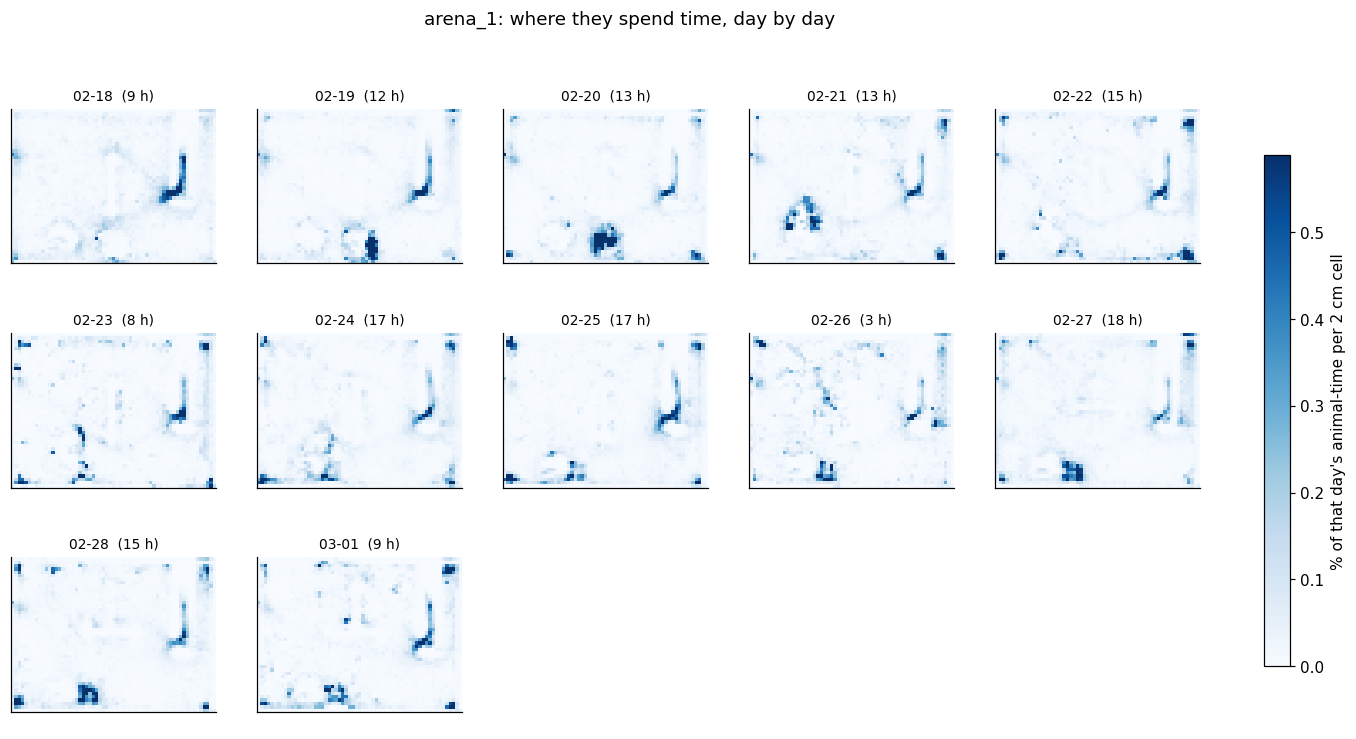

In [29]:
shown = [d for d in days if daily_seconds[d].sum() / 3600 >= 2]     # skip barely-observed days

shapes = {d: 100 * daily_seconds[d] / daily_seconds[d].sum() for d in shown}
top = max(np.percentile(m[m > 0], 99) for m in shapes.values())

columns = 5
rows_needed = -(-len(shown) // columns)
fig, axes = plt.subplots(rows_needed, columns, figsize=(3.0*columns, 2.5*rows_needed),
                         sharex=True, sharey=True)

for ax, day in zip(axes.ravel(), shown):
    mesh = ax.pcolormesh(x_edges, y_edges, shapes[day].T, cmap="Blues",
                         vmin=0, vmax=top, shading="auto")
    ax.set_title(f"{day.strftime('%m-%d')}  ({daily_seconds[day].sum()/3600:.0f} h)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal"); ax.grid(False)

for ax in axes.ravel()[len(shown):]:
    ax.axis("off")

fig.colorbar(mesh, ax=axes, label=f"% of that day's animal-time per {BIN_CM} cm cell",
             fraction=0.02)
fig.suptitle(f"{DAY_LOCATION}: where they spend time, day by day")
plt.show()

In [30]:
# Put a number on the drift: correlate each day's map with the next.
consecutive = []
for earlier, later in zip(shown, shown[1:]):
    r = np.corrcoef(shapes[earlier].ravel(), shapes[later].ravel())[0, 1]
    consecutive.append({"from": earlier, "to": later, "correlation": round(r, 2)})

pd.DataFrame(consecutive)

,from,to,correlation
0,2026-02-18,2026-02-19,0.49
1,2026-02-19,2026-02-20,0.39
2,2026-02-20,2026-02-21,0.24
3,2026-02-21,2026-02-22,0.53
4,2026-02-22,2026-02-23,0.53
5,2026-02-23,2026-02-24,0.54
6,2026-02-24,2026-02-25,0.81
7,2026-02-25,2026-02-26,0.43
8,2026-02-26,2026-02-27,0.66
9,2026-02-27,2026-02-28,0.76
